In [27]:
import mne
import numpy as np
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import cohen_kappa_score
from sklearn.preprocessing import LabelEncoder
from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
%matplotlib inline
mne.set_log_level('WARNING')

In [28]:
DATA_PATH   = r"C:\Users\cazie\Downloads\BCICIV_2a_gdf"
LABELS_PATH = r"C:\Users\cazie\Downloads\true_labels"
EOG_CHANNELS = ['EOG-left', 'EOG-central', 'EOG-right']
TMIN = 0.5
TMAX = 4.5
N_SUBJECTS = 9

In [29]:
def load_train_session(subject_num):
    path = f"{DATA_PATH}\\A0{subject_num}T.gdf"
    raw = mne.io.read_raw_gdf(path, preload=True, verbose=False)
    raw.filter(l_freq=0.5, h_freq=40.0, verbose=False)
    existing_eog = [c for c in EOG_CHANNELS if c in raw.ch_names]
    if existing_eog:
        raw.drop_channels(existing_eog)
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    available = {k: event_id[k] for k in ['769','770','771','772'] if k in event_id}
    motor_events = {
        'left_hand':  available['769'],
        'right_hand': available['770'],
        'feet':       available['771'],
        'tongue':     available['772']
    }
    epochs = mne.Epochs(raw, events, event_id=motor_events,
                        tmin=TMIN, tmax=TMAX, baseline=None,
                        preload=True, verbose=False)
    X = epochs.get_data()
    id_to_label = {available['769']: 1, available['770']: 2,
                   available['771']: 3, available['772']: 4}
    y = np.array([id_to_label[e] for e in epochs.events[:, 2]])
    return X, y


def load_eval_session(subject_num):
    gdf_path = f"{DATA_PATH}\\A0{subject_num}E.gdf"
    mat_path = f"{LABELS_PATH}\\A0{subject_num}E.mat"
    raw = mne.io.read_raw_gdf(gdf_path, preload=True, verbose=False)
    raw.filter(l_freq=0.5, h_freq=40.0, verbose=False)
    existing_eog = [c for c in EOG_CHANNELS if c in raw.ch_names]
    if existing_eog:
        raw.drop_channels(existing_eog)
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    cue_id = event_id.get('768', None)
    trial_events = events[events[:, 2] == cue_id]
    epochs = mne.Epochs(raw, trial_events, event_id={'cue': cue_id},
                        tmin=TMIN, tmax=TMAX, baseline=None,
                        preload=True, verbose=False)
    X = epochs.get_data()
    mat = scipy.io.loadmat(mat_path)
    y = mat['classlabel'].flatten().astype(int)
    n = min(len(X), len(y))
    return X[:n], y[:n]

In [30]:
class EEGNet(nn.Module):
    def __init__(self, n_channels=22, n_times=1001, n_classes=4,
                 F1=8, D=2, F2=16, dropout_rate=0.5):
        super(EEGNet, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1)
        )
        self.depthwise = nn.Sequential(
            nn.Conv2d(F1, F1*D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout_rate)
        )
        self.separable = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, kernel_size=(1, 16), padding=(0, 8), groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout_rate)
        )
        self.flat_size = self._get_flat_size(n_channels, n_times)
        self.classifier = nn.Linear(self.flat_size, n_classes)

    def _get_flat_size(self, n_channels, n_times):
        x = torch.zeros(1, 1, n_channels, n_times)
        x = self.block1(x)
        x = self.depthwise(x)
        x = self.separable(x)
        return x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.block1(x)
        x = self.depthwise(x)
        x = self.separable(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [31]:
csp_results = []

for s in range(1, N_SUBJECTS + 1):
    X_train, y_train = load_train_session(s)
    X_test,  y_test  = load_eval_session(s)
    pipeline = Pipeline([
        ('CSP', CSP(n_components=4, reg=None, log=True, norm_trace=False)),
        ('LDA', LinearDiscriminantAnalysis())
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    csp_results.append({
        'Subject': f'S{s:02d}',
        'Accuracy': round(np.mean(y_pred == y_test), 3),
        'Kappa':    round(cohen_kappa_score(y_test, y_pred), 3)
    })
    print(f"S{s:02d} acc={csp_results[-1]['Accuracy']:.3f}")

df_csp = pd.DataFrame(csp_results)
df_csp.loc[len(df_csp)] = ['MEAN',
    round(df_csp['Accuracy'].mean(), 3),
    round(df_csp['Kappa'].mean(), 3)]
print("\n=== CSP + LDA ===")
print(df_csp.to_string(index=False))

C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


S01 acc=0.462


C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


S02 acc=0.358


C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

S07 acc=0.302


C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


S08 acc=0.413


C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


S09 acc=0.465

=== CSP + LDA ===
Subject  Accuracy  Kappa
    S01     0.462  0.282
    S02     0.358  0.144
    S03     0.406  0.208
    S04     0.233 -0.023
    S05     0.285  0.046
    S06     0.316  0.088
    S07     0.302  0.069
    S08     0.413  0.218
    S09     0.465  0.287
   MEAN     0.360  0.147


In [32]:
riem_results = []

for s in range(1, N_SUBJECTS + 1):
    X_train, y_train = load_train_session(s)
    X_test,  y_test  = load_eval_session(s)
    cov = Covariances(estimator='oas')
    ts  = TangentSpace(metric='riemann')
    clf = LogisticRegression(max_iter=1000, C=1.0)
    cov_train = cov.fit_transform(X_train)
    ts_train  = ts.fit_transform(cov_train)
    clf.fit(ts_train, y_train)
    cov_test = cov.transform(X_test)
    ts_test  = ts.transform(cov_test)
    y_pred   = clf.predict(ts_test)
    riem_results.append({
        'Subject': f'S{s:02d}',
        'Accuracy': round(np.mean(y_pred == y_test), 3),
        'Kappa':    round(cohen_kappa_score(y_test, y_pred), 3)
    })
    print(f"S{s:02d} acc={riem_results[-1]['Accuracy']:.3f}")

df_riem = pd.DataFrame(riem_results)
df_riem.loc[len(df_riem)] = ['MEAN',
    round(df_riem['Accuracy'].mean(), 3),
    round(df_riem['Kappa'].mean(), 3)]
print("\n=== Riemannian TS + LR ===")
print(df_riem.to_string(index=False))

C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


S01 acc=0.566


C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


S02 acc=0.382


C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

S07 acc=0.344


C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


S08 acc=0.538


C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


S09 acc=0.646

=== Riemannian TS + LR ===
Subject  Accuracy  Kappa
    S01     0.566  0.421
    S02     0.382  0.176
    S03     0.531  0.375
    S04     0.420  0.227
    S05     0.389  0.185
    S06     0.403  0.204
    S07     0.344  0.125
    S08     0.538  0.384
    S09     0.646  0.528
   MEAN     0.469  0.292


In [34]:
eegnet_results = []

for s in range(1, N_SUBJECTS + 1):
    print(f"S{s:02d}...", end=" ", flush=True)
    X_train, y_train = load_train_session(s)
    X_test,  y_test  = load_eval_session(s)

    le = LabelEncoder()
    y_tr_enc = le.fit_transform(y_train)
    y_te_enc = le.transform(y_test)

    X_tr = torch.FloatTensor(X_train).unsqueeze(1)
    X_te = torch.FloatTensor(X_test).unsqueeze(1)
    y_tr = torch.LongTensor(y_tr_enc)

    mean = X_tr.mean(dim=(0,3), keepdim=True)
    std  = X_tr.std(dim=(0,3),  keepdim=True) + 1e-6
    X_tr = (X_tr - mean) / std
    X_te = (X_te - mean) / std

    model     = EEGNet(n_channels=X_train.shape[1], n_times=X_train.shape[2])
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    loader    = DataLoader(TensorDataset(X_tr, y_tr), batch_size=16, shuffle=True)

    model.train()
    for epoch in range(150):
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            criterion(model(X_batch), y_batch).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_te).argmax(dim=1).numpy()

    acc   = round(float(np.mean(preds == y_te_enc)), 3)
    kappa = round(cohen_kappa_score(y_te_enc, preds), 3)
    print(f"acc={acc:.3f}")
    eegnet_results.append({'Subject': f'S{s:02d}', 'Accuracy': acc, 'Kappa': kappa})

df_eegnet = pd.DataFrame(eegnet_results)
df_eegnet.loc[len(df_eegnet)] = ['MEAN',
    round(df_eegnet['Accuracy'].mean(), 3),
    round(df_eegnet['Kappa'].mean(), 3)]
print("\n=== EEGNet ===")
print(df_eegnet.to_string(index=False))

S01... 

C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


acc=0.389
S02... 

C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


acc=0.247
S03... 

...

acc=0.201
S08... 

C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


acc=0.312
S09... 

C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\cazie\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


acc=0.281

=== EEGNet ===
Subject  Accuracy  Kappa
    S01     0.389  0.185
    S02     0.247 -0.005
    S03     0.406  0.208
    S04     0.250  0.000
    S05     0.278  0.037
    S06     0.278  0.037
    S07     0.201 -0.065
    S08     0.312  0.083
    S09     0.281  0.042
   MEAN     0.294  0.058


In [35]:
subjects = [f'S{s:02d}' for s in range(1, 10)] + ['MEAN']

df_final = pd.DataFrame({
    'Subject':    subjects,
    'CSP+LDA':    df_csp['Accuracy'].tolist(),
    'Riemannian': df_riem['Accuracy'].tolist(),
    'EEGNet':     df_eegnet['Accuracy'].tolist(),
})

df_final['Best'] = df_final[['CSP+LDA','Riemannian','EEGNet']].max(axis=1)
print(df_final.to_string(index=False))

Subject  CSP+LDA  Riemannian  EEGNet  Best
    S01    0.462       0.566   0.389 0.566
    S02    0.358       0.382   0.247 0.382
    S03    0.406       0.531   0.406 0.531
    S04    0.233       0.420   0.250 0.420
    S05    0.285       0.389   0.278 0.389
    S06    0.316       0.403   0.278 0.403
    S07    0.302       0.344   0.201 0.344
    S08    0.413       0.538   0.312 0.538
    S09    0.465       0.646   0.281 0.646
   MEAN    0.360       0.469   0.294 0.469


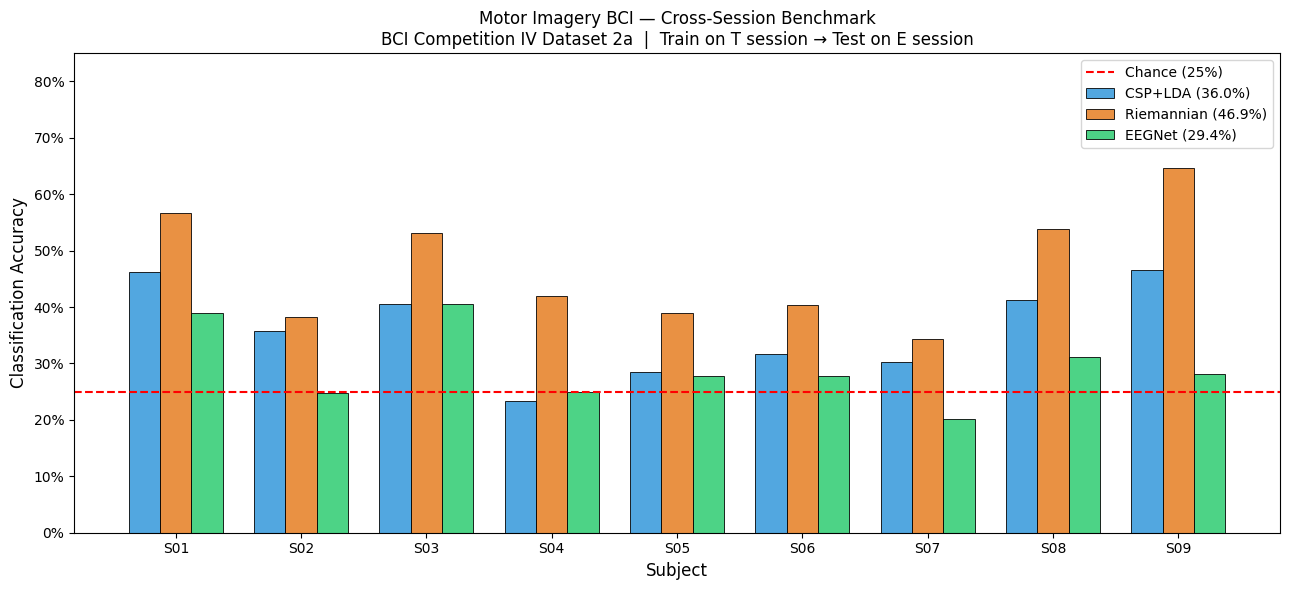

In [36]:
subjects_plot = [f'S{s:02d}' for s in range(1, 10)]
csp_vals  = df_csp[df_csp['Subject'] != 'MEAN']['Accuracy'].tolist()
riem_vals = df_riem[df_riem['Subject'] != 'MEAN']['Accuracy'].tolist()
eeg_vals  = df_eegnet[df_eegnet['Subject'] != 'MEAN']['Accuracy'].tolist()

x     = np.arange(len(subjects_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width, csp_vals,  width, label=f'CSP+LDA ({np.mean(csp_vals):.1%})',
       color='#3498db', alpha=0.85, edgecolor='black', linewidth=0.7)
ax.bar(x,         riem_vals, width, label=f'Riemannian ({np.mean(riem_vals):.1%})',
       color='#e67e22', alpha=0.85, edgecolor='black', linewidth=0.7)
ax.bar(x + width, eeg_vals,  width, label=f'EEGNet ({np.mean(eeg_vals):.1%})',
       color='#2ecc71', alpha=0.85, edgecolor='black', linewidth=0.7)

ax.axhline(y=0.25, color='red', linestyle='--', linewidth=1.5, label='Chance (25%)')
ax.set_xlabel('Subject', fontsize=12)
ax.set_ylabel('Classification Accuracy', fontsize=12)
ax.set_title('Motor Imagery BCI — Cross-Session Benchmark\nBCI Competition IV Dataset 2a  |  Train on T session → Test on E session',
             fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(subjects_plot)
ax.set_ylim(0, 0.85)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()